In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import json
import numpy as np
import re
import string
import nltk
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/namansethi/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [22]:
with open('Train/train_data1.json', 'r') as file: # Replace this path with the dataset path in your local machine
    data = json.load(file)

In [23]:
data

{'English-Bengali': {'Train': {'78683': {'source': 'Do not forget to visit the point where the Narmada flowing through the marble rocks interchanges its calmness and serenity into insouciance.',
    'target': 'এই জায়গাগুলো দেখতে ভুলো না যেখানে নর্মদা নদী মার্বেল পাথরের পাহাড়ের মধ্য দিয়ে প্রবাহিত হচ্ছে এবং নিজের শান্তি ও সৌন্দর্যকে অনাসক্তিতে পরিণত করছে।'},
   '78684': {'source': 'It is evident that the biggest cause of poverty is illiteracy .',
    'target': 'এই কথা স্পষ্ট যে দরিদ্রতার বড় কারণ হল অশিক্ষা ।'},
   '78685': {'source': 'The film was released theatrically on 12 April 2013.',
    'target': 'চলচ্চিত্রটি ২০১৩ সালের ১২ই এপ্রিল প্রেক্ষাগৃহে মুক্তি পায়।'},
   '78686': {'source': "is wyatt's birthday party at ten p. m.",
    'target': 'অনিমেষ এর জন্মদিনের পার্টি রাত দশটায়'},
   '78687': {'source': 'Apart from being used as an eatable, barley is also used in many other fields like industries and agriculture.',
    'target': 'খাদ্যদ্রব্য ছাড়াও যব আরো বিভিন্ন ক্ষেত্রে যেমন শিল্প ও

In [24]:
for language_pair, language_data in data.items():
  print(f"Language Pair: {language_pair}")

Language Pair: English-Bengali
Language Pair: English-Hindi


In [25]:
source_sentences_train = []

for language_pair, language_data in data.items():
    train_data = language_data.get("Train", {})
    for _, sample in train_data.items():
        source_sentences_train.append(sample["source"])

print(f"Total English sentences: {len(source_sentences_train)}")
print("Sample:", source_sentences_train[:3])

Total English sentences: 149646
Sample: ['Do not forget to visit the point where the Narmada flowing through the marble rocks interchanges its calmness and serenity into insouciance.', 'It is evident that the biggest cause of poverty is illiteracy .', 'The film was released theatrically on 12 April 2013.']


In [26]:
english_sentences = []

for language_pair, language_data in data.items():
    train_data = language_data.get("Train", {})
    for _, sample in train_data.items():
        english_sentences.append(sample["source"])

print(f"Total English sentences: {len(english_sentences)}")
print("Sample:", english_sentences[:3])

Total English sentences: 149646
Sample: ['Do not forget to visit the point where the Narmada flowing through the marble rocks interchanges its calmness and serenity into insouciance.', 'It is evident that the biggest cause of poverty is illiteracy .', 'The film was released theatrically on 12 April 2013.']


In [27]:
target_sentences_train = []

for language_pair, language_data in data.items():
    train_data = language_data.get("Train", {})
    for _, sample in train_data.items():
        target_sentences_train.append(sample["source"])

print(f"Total English sentences: {len(english_sentences)}")
print("Sample:", english_sentences[:3])

Total English sentences: 149646
Sample: ['Do not forget to visit the point where the Narmada flowing through the marble rocks interchanges its calmness and serenity into insouciance.', 'It is evident that the biggest cause of poverty is illiteracy .', 'The film was released theatrically on 12 April 2013.']


In [28]:
# Process JSON data
source_sentences_train_bengali = []
target_sentences_train_bengali = []

id_train_bengali = []


In [29]:
for language_pair, language_data in data.items():
    if(language_pair == "English-Bengali"):
      print(f"Language Pair: {language_pair}")
      for data_type, data_entries in language_data.items():
          print(f"  Data Type: {data_type}")
          for entry_id, entry_data in data_entries.items():
              source = entry_data["source"]
              target = entry_data["target"]
              # if (data_type == "Validation"):
              #   source_sentences_val_bengali.append(source)
              #   target_sentences_val_bengali.append(target)
              #   id_val_bengali.append(entry_id)
              # else:
              source_sentences_train_bengali.append(source)
              target_sentences_train_bengali.append(target)
              id_train_bengali.append(entry_id)

Language Pair: English-Bengali
  Data Type: Train


In [30]:
print(len(source_sentences_train_bengali)) 
print(len(target_sentences_train_bengali))

68849
68849


In [31]:
# Process JSON data
source_sentences_train_hindi = []
target_sentences_train_hindi = []

id_train_hindi = []

In [32]:
for language_pair, language_data in data.items():
    if(language_pair == "English-Hindi"):
      print(f"Language Pair: {language_pair}")
      for data_type, data_entries in language_data.items():
          print(f"  Data Type: {data_type}")
          for entry_id, entry_data in data_entries.items():
              source = entry_data["source"]
              target = entry_data["target"]
              # if (data_type == "Validation"):
              #   source_sentences_val_bengali.append(source)
              #   target_sentences_val_bengali.append(target)
              #   id_val_bengali.append(entry_id)
              # else:
              source_sentences_train_hindi.append(source)
              target_sentences_train_hindi.append(target)
              id_train_hindi.append(entry_id)

Language Pair: English-Hindi
  Data Type: Train


In [33]:
with open('Train/val_data1.json', 'r') as file: # Replace this path with the dataset path in your local machine
    data = json.load(file)

In [34]:
data

{'English-Bengali': {'Validation': {'147532': {'source': 'Food parks should be established away from towns and cities in the remote areas so that rural population gets benefits from them and cities do not get overcrowded .'},
   '147533': {'source': 'On one side is the Spiti valley and to the other are numerous C. B. (Chandra-Bhaga ) range peaks.'},
   '147534': {'source': 'The INF is responsible for compiling world rankings for national teams, maintaining the rules for netball and organising several major international competitions.'},
   '147535': {'source': 'The total population of the district was 192,795 in the 2001 census.'},
   '147536': {'source': 'Patali Srikhetra is a famous place with significant historical importance for Subarnapur district and Odisha, India.'},
   '147537': {'source': "what is today's exact date"},
   '147538': {'source': 'In Amitabh `s words only Pran gave life to the Hindi cinema through his artistry .'},
   '147539': {'source': 'This German scholar thro

In [35]:
# for language_pair, language_data in data.items():
#     if(language_pair == "English-Bengali"):
#       print(f"Language Pair: {language_pair}")
#       for data_type, data_entries in language_data.items():
#           print(f"  Data Type: {data_type}")
#           for entry_id, entry_data in data_entries.items():
#               source = entry_data["source"]
#               #target = entry_data["target"]
#               if (data_type == "Test"):
#                 source_sentences_val.append(source)
#                 #target_sentences_val.append(target)
#                 #id_val.append(entry_id)
#               #else:
#                 #source_sentences_train.append(source)
#                 #target_sentences_train.append(target)
#                 #id_train.append(entry_id)

In [36]:
source_sentences_val_bengali = []
id_val_bengali = []

for language_pair, language_data in data.items():
    if(language_pair == "English-Bengali"):
      print(f"Language Pair: {language_pair}")
      for data_type, data_entries in language_data.items():
          print(f"  Data Type: {data_type}")
          for entry_id, entry_data in data_entries.items():
              source = entry_data["source"]

              if (data_type == "Validation"):
                source_sentences_val_bengali.append(source)
                id_val_bengali.append(entry_id)
              # else:
              #   source_sentences_train.append(source)
              #   target_sentences_train.append(target)
              #   id_train.append(entry_id)

Language Pair: English-Bengali
  Data Type: Validation


In [37]:
print(len(source_sentences_val_bengali))

9836


In [38]:
source_sentences_val_hindi = []
id_val_hindi = []

for language_pair, language_data in data.items():
    if(language_pair == "English-Hindi"):
      print(f"Language Pair: {language_pair}")
      for data_type, data_entries in language_data.items():
          print(f"  Data Type: {data_type}")
          for entry_id, entry_data in data_entries.items():
              source = entry_data["source"]

              if (data_type == "Validation"):
                source_sentences_val_hindi.append(source)
                id_val_hindi.append(entry_id)
              # else:
              #   source_sentences_train.append(source)
              #   target_sentences_train.append(target)
              #   id_train.append(entry_id)

Language Pair: English-Hindi
  Data Type: Validation


In [39]:
print(len(source_sentences_train_bengali))
print(len(target_sentences_train_bengali))
print(len(id_train_bengali))

print(len(source_sentences_train_hindi))
print(len(target_sentences_train_hindi))
print(len(id_train_hindi))

print(len(source_sentences_val_bengali))
print(len(id_val_bengali))

print(len(source_sentences_val_hindi))
print(len(id_val_hindi))


68849
68849
68849
80797
80797
80797
9836
9836
11543
11543


In [40]:
source_sentences_val_bengali

['Food parks should be established away from towns and cities in the remote areas so that rural population gets benefits from them and cities do not get overcrowded .',
 'On one side is the Spiti valley and to the other are numerous C. B. (Chandra-Bhaga ) range peaks.',
 'The INF is responsible for compiling world rankings for national teams, maintaining the rules for netball and organising several major international competitions.',
 'The total population of the district was 192,795 in the 2001 census.',
 'Patali Srikhetra is a famous place with significant historical importance for Subarnapur district and Odisha, India.',
 "what is today's exact date",
 'In Amitabh `s words only Pran gave life to the Hindi cinema through his artistry .',
 'This German scholar through the scientific method carried at his Maclawerg agricultural farm came to the conclusion that economic elements are more powerful as compared to the physical elements in the localization of agriculture .',
 'Your GP will 

In [41]:
x={'English':source_sentences_train_hindi,'Hindi':target_sentences_train_hindi}
y ={'English':source_sentences_train_bengali,'Bengali':target_sentences_train_bengali}

x_test ={'English':source_sentences_val_hindi}
y_test = {'English':source_sentences_val_bengali}

In [42]:
len(y['Bengali'])

68849

In [43]:
df_hindi = pd.DataFrame(x)
df_bengali = pd.DataFrame(y)

df_hindi_test = pd.DataFrame(x_test)
df_bengali_test = pd.DataFrame(y_test)

In [44]:
df_hindi_test

,English
0,"Somebody on this side, what will be my goal-test?"
1,Avoid alcohol and illicit drugs.
2,"Barley is also used for malt production, which..."
3,Rana Daggubati shed 15 kilograms for this film...
4,"Cradle Mountain-Lake St Clair National Park, a..."
...,...
11538,"Harsha along with his son Bhoja were murdered,..."
11539,This mainly happens in areas that tend to have...
11540,Show me all centres in state Himachal Pradesh ...
11541,"In 2018, 1–2.5 % of people commute by bike in ..."


In [45]:
df_bengali.iloc[0]

English    Do not forget to visit the point where the Nar...
Bengali    এই জায়গাগুলো দেখতে ভুলো না যেখানে নর্মদা নদী ম...
Name: 0, dtype: object

In [46]:
import nltk
from collections import Counter

In [47]:
# # Function to preprocess and remove punctuation and numbers
# def preprocess_and_remove_punctuation(sentence):
#     # Remove punctuation and numbers
#     sentence = ''.join([char for char in sentence if char not in string.punctuation and not char.isdigit()])
#     return sentence

# df_bengali['English_tokens'] = df_bengali['English'].apply(preprocess_and_remove_punctuation)
# df_hindi['English_tokens'] = df_hindi['English'].apply(preprocess_and_remove_punctuation)
# df_bengali

In [48]:
from nltk.tokenize import word_tokenize

def preprocess(sentence):
    return [word_tokenize(sentence.lower().strip())]

df_bengali['English_tokens'] = df_bengali['English'].apply(preprocess)
df_hindi['English_tokens'] = df_hindi['English'].apply(preprocess)

df_hindi_test['English_tokens'] = df_hindi_test['English'].apply(preprocess)
df_bengali_test['English_tokens'] = df_bengali_test['English'].apply(preprocess)

In [49]:
df_hindi.iloc[0]['English_tokens']

[['cancel', 'everything', 'on', 'my', 'calendar']]

In [50]:
df_hindi

,English,Hindi,English_tokens
0,cancel everything on my calendar,मेरे कैलेंडर पर सब कुछ रद्द करें,"[[cancel, everything, on, my, calendar]]"
1,Adrenal hormone levels are at their peak durin...,अधिवृक्क के हार्मोन का स्तर प्रातःकाल में अपने...,"[[adrenal, hormone, levels, are, at, their, pe..."
2,"Golden threads are obtained from Surat, the qu...","स्वर्ण धागे सूरत से प्राप्त होते हैं, जिनकी गु...","[[golden, threads, are, obtained, from, surat,..."
3,Look for agglutination within 30 seconds.,30 सेकेण्ड के भीतर एग्लूटिनेशन देखें।,"[[look, for, agglutination, within, 30, second..."
4,The non-pompousness and informality of their l...,उनके जीवन की आडंबरहीनता एवं अनौपचारिकता उनके स...,"[[the, non-pompousness, and, informality, of, ..."
...,...,...,...
80792,"So, is it that this is the optimization proble...","तो, यह अनुकूलन समस्या है जिसमें हम रुचि रखते थे।","[[so, ,, is, it, that, this, is, the, optimiza..."
80793,In this Masjid made with red stones there are ...,लाल पत्थरों से बनायी गयी इस मस्जिद में हिन्दू ...,"[[in, this, masjid, made, with, red, stones, t..."
80794,"He began to work on the movie on August 17, 20...","उन्होंने 17 अगस्त, 2010 को फिल्म पर काम करना श...","[[he, began, to, work, on, the, movie, on, aug..."
80795,start a new shopping list,एक नई खरीदारी सूची शुरू करें,"[[start, a, new, shopping, list]]"


In [51]:
df_hindi_test

,English,English_tokens
0,"Somebody on this side, what will be my goal-test?","[[somebody, on, this, side, ,, what, will, be,..."
1,Avoid alcohol and illicit drugs.,"[[avoid, alcohol, and, illicit, drugs, .]]"
2,"Barley is also used for malt production, which...","[[barley, is, also, used, for, malt, productio..."
3,Rana Daggubati shed 15 kilograms for this film...,"[[rana, daggubati, shed, 15, kilograms, for, t..."
4,"Cradle Mountain-Lake St Clair National Park, a...","[[cradle, mountain-lake, st, clair, national, ..."
...,...,...
11538,"Harsha along with his son Bhoja were murdered,...","[[harsha, along, with, his, son, bhoja, were, ..."
11539,This mainly happens in areas that tend to have...,"[[this, mainly, happens, in, areas, that, tend..."
11540,Show me all centres in state Himachal Pradesh ...,"[[show, me, all, centres, in, state, himachal,..."
11541,"In 2018, 1–2.5 % of people commute by bike in ...","[[in, 2018, ,, 1–2.5, %, of, people, commute, ..."


In [52]:
# The path to the local git repo for Indic NLP library
INDIC_NLP_LIB_HOME=r"indic_nlp_library"

# The path to the local git repo for Indic NLP Resources
INDIC_NLP_RESOURCES="indic_nlp_resources"

import sys
sys.path.append(r'{}'.format(INDIC_NLP_LIB_HOME))

from indicnlp import common
common.set_resources_path(INDIC_NLP_RESOURCES)

from indicnlp import loader
loader.load()

In [53]:
from indicnlp.normalize.indic_normalize import BaseNormalizer


normalizer_hi = BaseNormalizer("hi", remove_nuktas=False)
normalizer_bengali = BaseNormalizer("bn", remove_nuktas=False)

# Step 2: Define a normalization function
def normalize_text(text, normalizer):
    if isinstance(text, str):
        return normalizer.normalize(text)
    return text  # leave non-strings unchanged

df_hindi["Hindi"] = df_hindi["Hindi"].apply(lambda x: normalize_text(x, normalizer_hi))
df_bengali["Bengali"] = df_bengali["Bengali"].apply(lambda x: normalize_text(x, normalizer_bengali))


In [54]:
from indicnlp.tokenize import indic_tokenize

def preprocess_indic_sentence(sentence, lang):
    return indic_tokenize.trivial_tokenize(sentence.strip(), lang=lang)

# Apply to Bengali column
df_bengali['Bengali_tokens'] = df_bengali['Bengali'].apply(lambda x: preprocess_indic_sentence(x, 'bn'))

# Similarly for Hindi
df_hindi['Hindi_tokens'] = df_hindi['Hindi'].apply(lambda x: preprocess_indic_sentence(x, 'hi'))


In [55]:
df_bengali['English_tokens'] = df_bengali['English_tokens'].apply(lambda x: x[0] if isinstance(x[0], list) else x)
df_hindi['English_tokens'] = df_hindi['English_tokens'].apply(lambda x: x[0] if isinstance(x[0], list) else x)


In [56]:
df_hindi_test['English_tokens'] = df_hindi_test['English_tokens'].apply(lambda x: x[0] if isinstance(x[0], list) else x)
df_bengali_test['English_tokens'] = df_bengali_test['English_tokens'].apply(lambda x: x[0] if isinstance(x[0], list) else x)


In [57]:
df_hindi

,English,Hindi,English_tokens,Hindi_tokens
0,cancel everything on my calendar,मेरे कैलेंडर पर सब कुछ रद्द करें,"[cancel, everything, on, my, calendar]","[मेरे, कैलेंडर, पर, सब, कुछ, रद्द, करें]"
1,Adrenal hormone levels are at their peak durin...,अधिवृक्क के हार्मोन का स्तर प्रातःकाल में अपने...,"[adrenal, hormone, levels, are, at, their, pea...","[अधिवृक्क, के, हार्मोन, का, स्तर, प्रातःकाल, म..."
2,"Golden threads are obtained from Surat, the qu...","स्वर्ण धागे सूरत से प्राप्त होते हैं, जिनकी गु...","[golden, threads, are, obtained, from, surat, ...","[स्वर्ण, धागे, सूरत, से, प्राप्त, होते, हैं, ,..."
3,Look for agglutination within 30 seconds.,30 सेकेण्ड के भीतर एग्लूटिनेशन देखें।,"[look, for, agglutination, within, 30, seconds...","[30, सेकेण्ड, के, भीतर, एग्लूटिनेशन, देखें, ।]"
4,The non-pompousness and informality of their l...,उनके जीवन की आडंबरहीनता एवं अनौपचारिकता उनके स...,"[the, non-pompousness, and, informality, of, t...","[उनके, जीवन, की, आडंबरहीनता, एवं, अनौपचारिकता,..."
...,...,...,...,...
80792,"So, is it that this is the optimization proble...","तो, यह अनुकूलन समस्या है जिसमें हम रुचि रखते थे।","[so, ,, is, it, that, this, is, the, optimizat...","[तो, ,, यह, अनुकूलन, समस्या, है, जिसमें, हम, र..."
80793,In this Masjid made with red stones there are ...,लाल पत्थरों से बनायी गयी इस मस्जिद में हिन्दू ...,"[in, this, masjid, made, with, red, stones, th...","[लाल, पत्थरों, से, बनायी, गयी, इस, मस्जिद, में..."
80794,"He began to work on the movie on August 17, 20...","उन्होंने 17 अगस्त, 2010 को फिल्म पर काम करना श...","[he, began, to, work, on, the, movie, on, augu...","[उन्होंने, 17, अगस्त, ,, 2010, को, फिल्म, पर, ..."
80795,start a new shopping list,एक नई खरीदारी सूची शुरू करें,"[start, a, new, shopping, list]","[एक, नई, खरीदारी, सूची, शुरू, करें]"


In [58]:
# target_sentences_train = [re.sub(r'[a-zA-Z]','',hi) for hi in target_sentences_train] #optional

In [59]:
english_tokens_h = df_hindi['English_tokens']
english_tokens_b = df_bengali['English_tokens']
english_test_h = df_hindi_test['English_tokens']
english_test_b = df_bengali_test['English_tokens']
hindi_tokens = df_hindi['Hindi_tokens']
bengali_tokens = df_bengali['Bengali_tokens']
# hindi_test=preprocess(target_sentences_val)

In [60]:
print(len(english_tokens_b))
print(len(bengali_tokens))

68849
68849


In [61]:
en_train=english_tokens_h
en_test=english_test_h
de_train=hindi_tokens
# de_test=hindi_test

In [62]:
english_tokens_b

0        [do, not, forget, to, visit, the, point, where...
1        [it, is, evident, that, the, biggest, cause, o...
2        [the, film, was, released, theatrically, on, 1...
3        [is, wyatt, 's, birthday, party, at, ten, p., ...
4        [apart, from, being, used, as, an, eatable, ,,...
                               ...                        
68844    [but, it, is, evident, that, there, is, change...
68845    [include, a, detailed, listing, of, all, of, y...
68846    [each, subcategory, counts, as, one, page, ,, ...
68847    [it, is, one, of, the, country, 's, oldest, st...
68848    [it, will, also, put, an, end, to, the, unnece...
Name: English_tokens, Length: 68849, dtype: object

In [63]:
print(type(en_train[0]))
print(en_train[0])


<class 'list'>
['cancel', 'everything', 'on', 'my', 'calendar']


In [64]:
en_index2word = ["<PAD>", "<SOS>", "<EOS>", "<UNK>"]
de_index2word = ["<PAD>", "<SOS>", "<EOS>", "<UNK>"]

for ds in [en_train, en_test]:   # Include both
    for sent in ds:
        for token in sent:
            if token not in en_index2word:
                en_index2word.append(token)

for ds in [de_train]:            # Only train for Hindi/Bengali
    for sent in ds:
        for token in sent:
            if token not in de_index2word:
                de_index2word.append(token)


flat_en_index2word = []
for token in en_index2word:
    if isinstance(token, list):
        flat_en_index2word.extend(token)  # add each token separately
    else:
        flat_en_index2word.append(token)

en_index2word = flat_en_index2word

en_word2index = {token: idx for idx, token in enumerate(en_index2word)}
de_word2index = {token: idx for idx, token in enumerate(de_index2word)}

en_lengths = sum([len(sent) for sent in en_train])/len(en_train)
de_lengths = sum([len(sent) for sent in de_train])/len(de_train)

def encode_and_pad(vocab, sent, max_length):
    sos = [vocab["<SOS>"]]
    eos = [vocab["<EOS>"]]
    pad = [vocab["<PAD>"]]

    if len(sent) < max_length - 2: # -2 for SOS and EOS
        n_pads = max_length - 2 - len(sent)
        encoded = [vocab[w] for w in sent]
        return sos + encoded + eos + pad * n_pads
    else: # sent is longer than max_length; truncating
        encoded = [vocab[w] for w in sent]
        truncated = encoded[:max_length - 2]
        return sos + truncated + eos

seq_length = 20
en_train_encoded = [encode_and_pad(en_word2index, sent, seq_length) for sent in en_train]
en_test_encoded = [encode_and_pad(en_word2index, sent, seq_length) for sent in en_test]
de_train_encoded = [encode_and_pad(de_word2index, sent, seq_length) for sent in de_train]
#de_test_encoded = [encode_and_pad(de_word2index, sent, seq_length) for sent in de_test]

batch_size = 50

train_x = np.array(en_train_encoded)
train_y = np.array(de_train_encoded)
test_x = np.array(en_test_encoded)
#test_y = np.array(de_test_encoded)

train_ds = TensorDataset(torch.from_numpy(train_x), torch.from_numpy(train_y))
test_ds = TensorDataset(torch.from_numpy(test_x))


train_dl = DataLoader(train_ds, shuffle=True, batch_size=batch_size, drop_last=True)
test_dl = DataLoader(test_ds, shuffle=True, batch_size=batch_size, drop_last=True)

In [65]:
en_index2word

['<PAD>',
 '<SOS>',
 '<EOS>',
 '<UNK>',
 'cancel',
 'everything',
 'on',
 'my',
 'calendar',
 'adrenal',
 'hormone',
 'levels',
 'are',
 'at',
 'their',
 'peak',
 'during',
 'the',
 'morning',
 'and',
 'taper',
 'off',
 'evening',
 ',',
 'reaching',
 'a',
 'low',
 'level',
 'around',
 '3',
 'am',
 'an',
 'important',
 'function',
 'of',
 'these',
 'hormones',
 'is',
 'to',
 'regulate',
 'vascular',
 'muscle',
 'tone',
 'prevent',
 'vasocodilation',
 '.',
 'golden',
 'threads',
 'obtained',
 'from',
 'surat',
 'quality',
 'being',
 '1200',
 'yards',
 '(',
 '1080',
 'meters',
 ')',
 'per',
 'tola',
 '11.664',
 'grams',
 'look',
 'for',
 'agglutination',
 'within',
 '30',
 'seconds',
 'non-pompousness',
 'informality',
 'life',
 'reflected',
 'in',
 'literature',
 'also',
 'world',
 'chess',
 'championship',
 '2006',
 'which',
 'kramnik',
 'beat',
 'fide',
 'champion',
 'veselin',
 'topalov',
 'reunified',
 'titles',
 'made',
 'undisputed',
 'heavily',
 'embroidered',
 'rugs',
 'shawls',


In [66]:
de_index2word

['<PAD>',
 '<SOS>',
 '<EOS>',
 '<UNK>',
 'मेरे',
 'कैलेंडर',
 'पर',
 'सब',
 'कुछ',
 'रद्द',
 'करें',
 'अधिवृक्क',
 'के',
 'हार्मोन',
 'का',
 'स्तर',
 'प्रातःकाल',
 'में',
 'अपने',
 'शिखर',
 'होता',
 'है',
 'और',
 'लगभग',
 'दोपहर',
 '३',
 'बजे',
 'एक',
 'निम्न',
 'पहुंचते',
 'हुए',
 ',',
 'संध्याकाल',
 'धीरे',
 '-',
 'कम',
 'हो',
 'जाता',
 '।',
 'इन',
 'हार्मोनों',
 'वाहिकीय',
 'मांसपेशी',
 'तान',
 'को',
 'नियंत्रित',
 'करने',
 'वाहिकाविस्फार',
 'से',
 'बचाने',
 'महत्त्वपूर्ण',
 'स्वर्ण',
 'धागे',
 'सूरत',
 'प्राप्त',
 'होते',
 'हैं',
 'जिनकी',
 'गुणवत्ता',
 '1200',
 'गज़',
 '(',
 '1080',
 'मीटर',
 ')',
 'प्रति',
 'तोला',
 '11.664',
 'ग्राम',
 '30',
 'सेकेण्ड',
 'भीतर',
 'एग्लूटिनेशन',
 'देखें',
 'उनके',
 'जीवन',
 'की',
 'आडंबरहीनता',
 'एवं',
 'अनौपचारिकता',
 'साहित्य',
 'भी',
 'प्रतिबिंबित',
 'होती',
 'विश्व',
 'शतरंज',
 'चैम्पियनशिप',
 '2006',
 'जिसमें',
 'क्रैमनिक',
 'ने',
 'एफ',
 '.',
 'आई',
 'डी',
 'ई',
 'चैंपियन',
 'वेसलिन',
 'टोपालोव',
 'हराया',
 'था',
 'खिताब',
 'फिर',
 'एकीकृत',

In [67]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [68]:
flat_en_index2word = []
for token in en_index2word:
    if isinstance(token, list):
        flat_en_index2word.extend(token)  # add each token separately
    else:
        flat_en_index2word.append(token)

en_index2word = flat_en_index2word



In [69]:
en_word2index = {token: idx for idx, token in enumerate(en_index2word)}
de_word2index = {token: idx for idx, token in enumerate(de_index2word)}

In [70]:
len(en_word2index)

66768

In [71]:
en_lengths = sum([len(sent) for sent in en_train])/len(en_train)
de_lengths = sum([len(sent) for sent in de_train])/len(de_train)

In [72]:

seq_length = 20

In [73]:
def encode_and_pad(vocab, sent, max_length):
    sos = [vocab["<SOS>"]]
    eos = [vocab["<EOS>"]]
    pad = [vocab["<PAD>"]]

    if len(sent) < max_length - 2: # -2 for SOS and EOS
        n_pads = max_length - 2 - len(sent)
        encoded = [vocab[w] for w in sent]
        return sos + encoded + eos + pad * n_pads
    else: # sent is longer than max_length; truncating
        encoded = [vocab[w] for w in sent]
        truncated = encoded[:max_length - 2]
        return sos + truncated + eos

In [74]:
en_test

0        [somebody, on, this, side, ,, what, will, be, ...
1                 [avoid, alcohol, and, illicit, drugs, .]
2        [barley, is, also, used, for, malt, production...
3        [rana, daggubati, shed, 15, kilograms, for, th...
4        [cradle, mountain-lake, st, clair, national, p...
                               ...                        
11538    [harsha, along, with, his, son, bhoja, were, m...
11539    [this, mainly, happens, in, areas, that, tend,...
11540    [show, me, all, centres, in, state, himachal, ...
11541    [in, 2018, ,, 1–2.5, %, of, people, commute, b...
11542                      [how, do, i, cook, a, meatloaf]
Name: English_tokens, Length: 11543, dtype: object

In [75]:
en_train_encoded = [encode_and_pad(en_word2index, sent, seq_length) for sent in en_train]
en_test_encoded = [encode_and_pad(en_word2index, sent, seq_length) for sent in en_test]
de_train_encoded = [encode_and_pad(de_word2index, sent, seq_length) for sent in de_train]
#de_test_encoded = [encode_and_pad(de_word2index, sent, seq_length) for sent in de_test]

In [76]:
en_train_encoded[1]

[1, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 16, 17, 22, 23, 24, 2]

In [77]:
batch_size = 50

train_x = np.array(en_train_encoded)
train_y = np.array(de_train_encoded)
test_x = np.array(en_test_encoded)
#test_y = np.array(de_test_encoded)

train_ds = TensorDataset(torch.from_numpy(train_x), torch.from_numpy(train_y))
test_ds = TensorDataset(torch.from_numpy(test_x))


train_dl = DataLoader(train_ds, shuffle=True, batch_size=batch_size, drop_last=True)
test_dl = DataLoader(test_ds, shuffle=True, batch_size=batch_size, drop_last=True)

In [78]:
train_x[1]

array([ 1,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 16, 17, 22,
       23, 24,  2])

In [79]:
train_ds[1]

(tensor([ 1,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 16, 17, 22, 23,
         24,  2]),
 tensor([ 1, 11, 12, 13, 14, 15, 16, 17, 18, 19,  6, 20, 21, 22, 23, 24, 25, 26,
         27,  2]))

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class EncoderLSTM(nn.Module):
    def __init__(self, input_size, embedding_dim, hidden_size, num_layers=1):
        super(EncoderLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(input_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_size, num_layers, batch_first=True)

    def forward(self, x):
        embedded = self.embedding(x)
        outputs, (hidden, cell) = self.lstm(embedded)
        return outputs, (hidden, cell)

# -----------------------------

# Decoder: LSTM-based

# -----------------------------

class DecoderLSTM(nn.Module):
    def __init__(self, output_size, embedding_dim, hidden_size, num_layers=1):
        super(DecoderLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(output_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden, cell):
        input = input.unsqueeze(1)
        embedded = self.embedding(input)
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        prediction = self.softmax(self.fc(output.squeeze(1)))
        return prediction, hidden, cell
# -----------------------------

# Seq2Seq Wrapper

# -----------------------------

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        trg_len = trg.size(1)
        trg_vocab_size = self.decoder.fc.out_features  # number of output tokens

        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(self.device)

        # Encode source sentence
        _, (hidden, cell) = self.encoder(src)

        # First decoder input = <SOS> tokens
        input = trg[:, 0]

        for t in range(1, trg_len):
            output, hidden, cell = self.decoder(input, hidden, cell)
            outputs[:, t, :] = output
            # Pick top token from output distribution
            top1 = output.argmax(1)
            # Decide if teacher forcing
            input = trg[:, t] if torch.rand(1).item() < teacher_forcing_ratio else top1

        return outputs

In [81]:
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size

        # Embedding layer
        self.embedding = nn.Embedding(input_size, hidden_size, padding_idx=0)

        # GRU layer. The input and output are both of the same size
        #  since embedding size = hidden size in this example
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)

    def forward(self, input, hidden):
        # The inputs are first transformed into embeddings
        embedded = self.embedding(input)
        output = embedded

        # As in any RNN, the new input and the previous hidden states are fed
        #  into the model at each time step
        output, hidden = self.gru(output, hidden)
        return output, hidden

    def initHidden(self):
        # This method is used to create the innitial hidden states for the encoder
        return torch.zeros(1, batch_size, self.hidden_size)

class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(DecoderRNN, self).__init__()
        self.hidden_size = hidden_size

        # Embedding layer
        self.embedding = nn.Embedding(output_size, hidden_size, padding_idx=0)

        # The GRU layer
        self.gru = nn.GRU(hidden_size, hidden_size)

        # Fully-connected layer for scores
        self.out = nn.Linear(hidden_size, output_size)

        # Applying Softmax to the scores
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):
        # Feeding input through embedding layer
        output = self.embedding(input)

        # Applying an activation function (ReLu)
        output = F.relu(output)

        # Feeding input and previous hidden state
        output, hidden = self.gru(output, hidden)

        # Outputting scores from the final time-step
        output = self.softmax(self.out(output[0]))

        return output, hidden

    # We do not need an .initHidden() method for the decoder since the encoder output will act as input in the first decoder time-step

In [82]:
hidden_size = 128

In [83]:
seq_length = 20

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# -----------------------------
# Step 1. Define basic parameters
# -----------------------------

input_size = len(en_word2index)      # English vocabulary size
output_size = len(de_word2index)     # Hindi/Bengali vocabulary size
embedding_dim = 256
hidden_size = 512
num_layers = 1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# Step 2. Initialize encoder, decoder, and Seq2Seq model
# -----------------------------

encoder = EncoderLSTM(input_size, embedding_dim, hidden_size, num_layers).to(device)
decoder = DecoderLSTM(output_size, embedding_dim, hidden_size, num_layers).to(device)
model = Seq2Seq(encoder, decoder, device).to(device)

In [524]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=0)  # ignore <PAD> token

In [525]:
# -----------------------------

# Step 4. Training loop (example)

# -----------------------------

n_epochs = 5

for epoch in range(n_epochs):
    print(f"Here we go {epoch}")
    model.train()
    epoch_loss = 0

    for src, trg in train_dl:
        src, trg = src.to(device), trg.to(device)

        optimizer.zero_grad()
        output = model(src, trg)  # output shape: [batch_size, trg_len, output_dim]

        # Flatten for loss calculation
        output_dim = output.shape[-1]
        output = output[:, 1:].reshape(-1, output_dim)
        trg = trg[:, 1:].reshape(-1)

        loss = criterion(output, trg)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
        optimizer.step()
        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss/len(train_dl):.4f}")



Here we go 0
Epoch 1/5, Loss: 6.5702
Here we go 1
Epoch 2/5, Loss: 5.7396
Here we go 2
Epoch 3/5, Loss: 5.1954
Here we go 3
Epoch 4/5, Loss: 4.7362
Here we go 4
Epoch 5/5, Loss: 4.3401


In [528]:
from tqdm import tqdm

val_outs = []
model.eval()

with torch.no_grad():
    for i in tqdm(range(len(test_ds))):
        # ---- ENCODER ----
        input_tensor = test_ds[i][0].unsqueeze(0).to(device)  # (1, seq_len)
        encoder_outputs, (hidden, cell) = encoder(input_tensor)

        # ---- DECODER ----
        decoder_input = torch.tensor([en_word2index["<SOS>"]]).to(device)

        decoder_hidden, decoder_cell = hidden, cell
        result = []

        for di in range(seq_length):
            decoder_output, decoder_hidden, decoder_cell = decoder(
                decoder_input, decoder_hidden, decoder_cell
            )

            best_token = decoder_output.argmax(1).item()
            result.append(de_index2word[best_token])

            if best_token == de_word2index["<EOS>"]:
                break

            decoder_input = torch.tensor([best_token]).to(device)

        # Remove special tokens
        result = [tok for tok in result if tok not in ["<EOS>", "<PAD>", "<SOS>"]]
        val_outs.append(" ".join(result))

100%|██████████| 11543/11543 [07:23<00:00, 26.01it/s]


In [562]:
# encoder = EncoderRNN(len(en_index2word), hidden_size).to(device)
# decoder = DecoderRNN(hidden_size, len(de_index2word)).to(device)


In [357]:
encoder

EncoderRNN(
  (embedding): Embedding(66768, 128, padding_idx=0)
  (gru): GRU(128, 128, batch_first=True)
)

In [358]:
decoder

DecoderRNN(
  (embedding): Embedding(73140, 128, padding_idx=0)
  (gru): GRU(128, 128)
  (out): Linear(in_features=128, out_features=73140, bias=True)
  (softmax): LogSoftmax(dim=1)
)

In [359]:
criterion = nn.NLLLoss()
enc_optimizer = torch.optim.Adam(encoder.parameters(), lr = 3e-3)
dec_optimizer = torch.optim.Adam(decoder.parameters(), lr = 3e-3)

In [ ]:
losses = []
input_length = target_length = seq_length

SOS = en_word2index["<SOS>"]
EOS = en_word2index["<EOS>"]

epochs = 3

for epoch in range(epochs):
    for idx, batch in enumerate(train_dl):

        # Creating initial hidden states for the encoder
        encoder_hidden = encoder.initHidden()

        # Sending to device
        encoder_hidden = encoder_hidden.to(device)

        # Assigning the input and sending to device
        input_tensor = batch[0].to(device)

        # Assigning the output and sending to device
        target_tensor = batch[1].to(device)


        # Clearing gradients
        enc_optimizer.zero_grad()
        dec_optimizer.zero_grad()

        # Enabling gradient calculation
        with torch.set_grad_enabled(True):

            # Feeding batch into encoder
            encoder_output, encoder_hidden = encoder(input_tensor, encoder_hidden)

            # This is a placeholder tensor for decoder outputs. We send it to device as well
            dec_result = torch.zeros(target_length, batch_size, len(de_index2word)).to(device)

            # Creating a batch of SOS tokens which will all be fed to the decoder
            decoder_input = target_tensor[:, 0].unsqueeze(dim=0).to(device)

            # Creating initial hidden states of the decoder by copying encoder hidden states
            decoder_hidden = encoder_hidden

            # For each time-step in decoding:
            for i in range(1, target_length):

                # Feed input and previous hidden states
                decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)

                # Finding the best scoring word
                best = decoder_output.argmax(1)

                # Assigning next input as current best word
                decoder_input = best.unsqueeze(dim=0)

                # Creating an entry in the placeholder output tensor
                dec_result[i] = decoder_output


            # Creating scores and targets for loss calculation
            scores = dec_result.transpose(1, 0)[1:].reshape(-1, dec_result.shape[2])
            targets = target_tensor[1:].reshape(-1)

            # Calculating loss
            loss = criterion(scores, targets)

            # Performing backprop and clipping excess gradients
            loss.backward()

            torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1)
            torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=1)

            enc_optimizer.step()
            dec_optimizer.step()

            # Keeping track of loss
            losses.append(loss.item())
            if idx % 100 == 0:
                print(idx, sum(losses)/len(losses))

0 10.65506649017334
100 6.565465436123385
200 6.188790390147498
300 6.025708290429606
400 5.924002465464528
500 5.851526872364585
600 5.790862749896311
700 5.737715919755835
800 5.70142663165127
900 5.66575910883659
1000 5.634373269476495
1100 5.603988904719132
1200 5.577016890793418
1300 5.548590112887008
1400 5.525229960148203
1500 5.502053098151241
1600 5.482657388476265


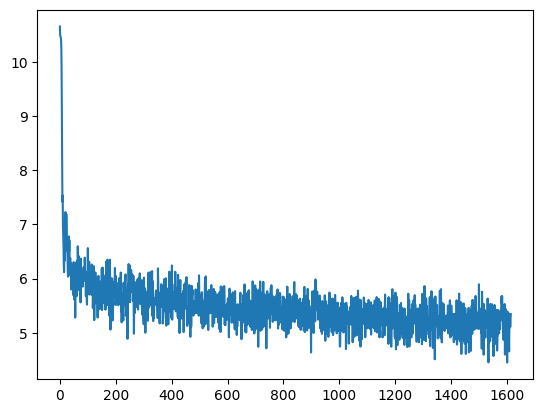

In [362]:
plt.plot(losses)

In [ ]:
from tqdm import tqdm

In [106]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# ------------------------------------
# Positional Encoding (for Transformers)
# ------------------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        x = x + self.pe[:, :x.size(1)]
        return x

# ------------------------------------
# Transformer Encoder
# ------------------------------------
class TransformerEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_heads=8, num_layers=3, dropout=0.1):
        super(TransformerEncoder, self).__init__()
        self.hidden_dim = hidden_dim
        
        # Embedding layer
        self.embedding = nn.Embedding(input_dim, hidden_dim, padding_idx=0)
        self.pos_encoder = PositionalEncoding(hidden_dim)

        # Transformer Encoder layers
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=n_heads, dim_feedforward=hidden_dim * 4, dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
    def forward(self, src, src_mask=None, src_key_padding_mask=None):
        # src: [batch_size, src_seq_len]
        embedded = self.embedding(src) * math.sqrt(self.hidden_dim)
        embedded = self.pos_encoder(embedded)
        memory = self.transformer_encoder(embedded, src_mask, src_key_padding_mask)
        return memory

# ------------------------------------
# Transformer Decoder
# ------------------------------------
class TransformerDecoder(nn.Module):
    def __init__(self, output_dim, hidden_dim, n_heads=8, num_layers=3, dropout=0.1):
        super(TransformerDecoder, self).__init__()
        self.hidden_dim = hidden_dim

        # Embedding layer
        self.embedding = nn.Embedding(output_dim, hidden_dim, padding_idx=0)
        self.pos_encoder = PositionalEncoding(hidden_dim)

        # Transformer Decoder layers
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=hidden_dim, nhead=n_heads, dim_feedforward=hidden_dim * 4, dropout=dropout, batch_first=True
        )
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        # Output projection layer
        self.fc_out = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, tgt, memory, tgt_mask=None, tgt_key_padding_mask=None, memory_key_padding_mask=None):
        # tgt: [batch_size, tgt_seq_len]
        embedded = self.embedding(tgt) * math.sqrt(self.hidden_dim)
        embedded = self.pos_encoder(embedded)
        output = self.transformer_decoder(
            embedded, memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=memory_key_padding_mask
        )
        output = self.fc_out(output)
        return output

# ------------------------------------
# Full Seq2Seq Transformer Model
# ------------------------------------
class TransformerSeq2Seq(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, hidden_dim=256, n_heads=8, num_layers=3, dropout=0.1):
        super(TransformerSeq2Seq, self).__init__()
        self.encoder = TransformerEncoder(src_vocab_size, hidden_dim, n_heads, num_layers, dropout)
        self.decoder = TransformerDecoder(tgt_vocab_size, hidden_dim, n_heads, num_layers, dropout)
        self.softmax = nn.LogSoftmax(dim=-1)
    
    def forward(self, src, tgt):
        memory = self.encoder(src)
        output = self.decoder(tgt, memory)
        return self.softmax(output)


In [107]:
src_vocab_size = len(en_word2index)
tgt_vocab_size = len(de_word2index)

model = TransformerSeq2Seq(src_vocab_size, tgt_vocab_size, hidden_dim=256, n_heads=8, num_layers=4).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

In [109]:
import torch
from tqdm import tqdm

epochs = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss(ignore_index=0)  # ignore <PAD>
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

def generate_square_subsequent_mask(size):
    mask = torch.triu(torch.ones(size, size), diagonal=1).bool()
    return mask  # True = future positions masked

# -----------------------------
# Training Loop (no teacher forcing)
# -----------------------------
for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for idx, batch in enumerate(tqdm(train_dl)):
        src, tgt = batch  # (batch_size, src_len), (batch_size, tgt_len)
        src, tgt = src.to(device), tgt.to(device)

        optimizer.zero_grad()

        batch_size = src.size(0)
        max_len = tgt.size(1)

        # Encode the source sequence
        memory = model.encoder(src)

        # Initialize decoder input with <SOS> token for all samples
        decoder_input = torch.full((batch_size, 1), en_word2index["<SOS>"], dtype=torch.long, device=device)

        all_logits = []

        # Autoregressive decoding (no teacher forcing)
        for t in range(max_len - 1):
            tgt_mask = generate_square_subsequent_mask(decoder_input.size(1)).to(device)

            # Decode one token at a time
            output = model.decoder(
                decoder_input, memory, tgt_mask=tgt_mask
            )  # shape: (batch, seq_len, vocab_size)

            logits = output[:, -1, :]  # get last token prediction for each sample
            all_logits.append(logits.unsqueeze(1))  # store for loss computation

            # Greedy decoding: pick the most likely next token
            next_tokens = logits.argmax(1).unsqueeze(1)
            decoder_input = torch.cat([decoder_input, next_tokens], dim=1)

        # Concatenate logits across time steps
        logits = torch.cat(all_logits, dim=1)  # (batch, seq_len-1, vocab_size)

        # Compute loss
        tgt_output = tgt[:, 1:]  # remove <SOS>
        logits = logits.reshape(-1, logits.size(-1))
        tgt_output = tgt_output.reshape(-1)
        loss = criterion(logits, tgt_output)

        # Backpropagation
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
        optimizer.step()

        total_loss += loss.item()

        if idx % 100 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Step [{idx}] | Avg Loss: {total_loss / (idx+1):.4f}")

    print(f"\n✅ Epoch {epoch+1} completed | Average Loss: {total_loss / len(train_dl):.4f}\n")


  0%|          | 1/1376 [00:05<2:05:00,  5.45s/it]

Epoch [1/5] | Step [0] | Avg Loss: 11.6371


  0%|          | 6/1376 [00:33<2:08:35,  5.63s/it]


KeyboardInterrupt: 

In [92]:
# source_sentences_val_hindi
# id_val_hindi

val_ids = id_val_hindi

In [367]:
val_outs = []
for i in tqdm(range(len (test_ds))):
  encoder_hidden = torch.zeros(1, 1, hidden_size).to(device)
  input_tensor = test_ds[i][0].unsqueeze(dim=0).to(device)
  result = []
  with torch.set_grad_enabled(False):
    encoder_output, encoder_hidden = encoder(input_tensor, encoder_hidden)
    decoder_input = torch.tensor([SOS]).unsqueeze(dim=0).to(device)
    decoder_hidden = encoder_hidden
    for di in range(1, target_length):
        decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
        best = decoder_output.argmax(1)
        result.append(de_index2word[best.to('cpu').item()])
        if best.item() == EOS:
            break

        decoder_input = best.unsqueeze(dim=0)
  result = [i for i in result if not i in ['<EOS>', '<PAD>', '<SOS>']]
  val_outs.append(" ".join(result))

100%|██████████| 11543/11543 [02:28<00:00, 77.78it/s]


In [84]:
import torch
import torch.nn as nn
import numpy as np

class EncoderRNN2(nn.Module):
    def __init__(self, input_size, hidden_size, embedding_matrix=None, freeze_embeddings=True):
        super().__init__()
        self.hidden_size = hidden_size

        if embedding_matrix is not None:
            num_embeddings, embedding_dim = embedding_matrix.shape
            self.embedding = nn.Embedding(num_embeddings, embedding_dim, padding_idx=0)
            self.embedding.weight = nn.Parameter(torch.tensor(embedding_matrix, dtype=torch.float32))
            self.embedding.weight.requires_grad = not freeze_embeddings
            self.embedding_proj = nn.Linear(embedding_dim, hidden_size) if embedding_dim != hidden_size else None
        else:
            self.embedding = nn.Embedding(input_size, hidden_size, padding_idx=0)
            self.embedding_proj = None

        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)

    def forward(self, input, hidden):
        embedded = self.embedding(input)
        if self.embedding_proj:
            embedded = self.embedding_proj(embedded)
        output, hidden = self.gru(embedded, hidden)
        return output, hidden

    def initHidden(self, batch_size=1, device=torch.device('cpu')):
        """
        Returns initial hidden state tensor for the encoder.
        Supports variable batch sizes and device placement.
        """
        return torch.zeros(1, batch_size, self.hidden_size, device=device)

def build_embedding_matrix(word2vec, word2index, emb_dim=300):
    embedding_matrix = np.zeros((len(word2index), emb_dim))
    for word, idx in word2index.items():
        if word in word2vec:
            embedding_matrix[idx] = word2vec[word]
        else:
            embedding_matrix[idx] = np.random.normal(scale=0.6, size=(emb_dim,))
    return embedding_matrix


In [85]:
import gensim.downloader as api
w2v_model = api.load('word2vec-google-news-300')

In [86]:
# 1️⃣ Load pretrained Word2Vec model
from gensim.models import KeyedVectors
src_w2v = w2v_model

# 2️⃣ Build embedding matrix for your encoder vocab
embedding_matrix = build_embedding_matrix(src_w2v, en_word2index, emb_dim=300)

In [87]:
hidden_size = 512
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder = EncoderRNN2(len(en_word2index), hidden_size, embedding_matrix, freeze_embeddings=True).to(device)
decoder = DecoderRNN(hidden_size, len(de_index2word)).to(device)


In [88]:
criterion = nn.NLLLoss()
enc_optimizer = torch.optim.Adam(encoder.parameters(), lr = 3e-3)
dec_optimizer = torch.optim.Adam(decoder.parameters(), lr = 3e-3)

In [89]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

# -----------------------------
# Training Hyperparameters
# -----------------------------
epochs = 1
batch_size = 50
teacher_forcing_ratio = 0.5  # Probability of using teacher forcing
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Assume train_dl is already a DataLoader yielding (input_tensor, target_tensor)
# and encoder, decoder, enc_optimizer, dec_optimizer, criterion are defined

# -----------------------------
# Training Loop
# -----------------------------
losses = []

for epoch in range(epochs):
    encoder.train()
    decoder.train()
    
    for idx, batch in enumerate(tqdm(train_dl)):
        input_tensor, target_tensor = batch
        batch_size_cur = input_tensor.size(0)
        max_target_len = target_tensor.size(1)  # actual sequence length
        
        input_tensor = input_tensor.to(device)
        target_tensor = target_tensor.to(device)
        
        # Initialize encoder hidden state
        encoder_hidden = encoder.initHidden(batch_size_cur, device)
        
        enc_optimizer.zero_grad()
        dec_optimizer.zero_grad()
        
        # Encoder forward
        encoder_outputs, encoder_hidden = encoder(input_tensor, encoder_hidden)
        
        # Prepare decoder input and hidden state
        decoder_input = target_tensor[:, 0].unsqueeze(0)  # <SOS> token
        decoder_hidden = encoder_hidden
        
        # Placeholder for decoder outputs
        dec_result = torch.zeros(max_target_len, batch_size_cur, len(de_index2word), device=device)
        
        # Decoder forward
        for t in range(1, max_target_len):
            decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
            dec_result[t] = decoder_output
            
            # Decide on teacher forcing
            use_teacher_forcing = np.random.random() < teacher_forcing_ratio
            if use_teacher_forcing:
                decoder_input = target_tensor[:, t].unsqueeze(0)  # Next target token
            else:
                decoder_input = decoder_output.argmax(1).unsqueeze(0)  # Predicted token
        
        # Compute loss
        scores = dec_result[1:].transpose(1, 0).reshape(-1, dec_result.shape[2])
        targets = target_tensor[:, 1:].reshape(-1)
        loss = criterion(scores, targets)
        
        # Backpropagation
        loss.backward()
        torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1)
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=1)
        enc_optimizer.step()
        dec_optimizer.step()
        
        losses.append(loss.item())
        
        if idx % 100 == 0:
            print(f"Epoch {epoch+1} | Batch {idx} | Avg Loss: {np.mean(losses):.4f}")


  0%|          | 1/1615 [00:01<45:51,  1.70s/it]

Epoch 1 | Batch 0 | Avg Loss: 11.2197


  6%|▋         | 101/1615 [02:30<36:32,  1.45s/it]

Epoch 1 | Batch 100 | Avg Loss: 6.6244


 12%|█▏        | 201/1615 [05:03<38:59,  1.65s/it]

...

 93%|█████████▎| 1501/1615 [47:50<03:55,  2.06s/it]

Epoch 1 | Batch 1500 | Avg Loss: 5.6467


 99%|█████████▉| 1601/1615 [51:15<00:28,  2.04s/it]

Epoch 1 | Batch 1600 | Avg Loss: 5.6079


100%|██████████| 1615/1615 [51:43<00:00,  1.92s/it]


In [97]:
from tqdm import tqdm
import torch

val_outs = []

encoder.eval()  # Ensure model is in eval mode
decoder.eval()

with torch.no_grad():
    for i in tqdm(range(len(test_ds))):
        # Get input sentence
        input_tensor = test_ds[i][0].unsqueeze(0).to(device)  # shape: (1, seq_len)

        # ---- ENCODER ----
        encoder_hidden = encoder.initHidden(1, device)
        encoder_outputs, encoder_hidden = encoder(input_tensor, encoder_hidden)

        # ---- DECODER ----
        decoder_input = torch.tensor([[SOS]]).to(device)
        decoder_hidden = encoder_hidden
        decoded_tokens = []

        for _ in range(seq_length):  # max target length
            decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
            best_token_idx = decoder_output.argmax(1).item()
            token = de_index2word[best_token_idx]

            if token == "<EOS>":
                break
            elif token not in ["<PAD>", "<SOS>"]:
                decoded_tokens.append(token)

            # Prepare input for next timestep
            decoder_input = torch.tensor([[best_token_idx]]).to(device)

        # Append prediction (even if empty)
        val_outs.append(" ".join(decoded_tokens))


100%|██████████| 11543/11543 [07:02<00:00, 27.33it/s]


In [98]:
df0 = pd.DataFrame()
df0["ID"] = val_ids
df0["Translation"] = val_outs

In [99]:
df0.to_csv('answersHindiRNN1.csv', index = False)

In [100]:
x=pd.read_csv("answersHindiRNN1.csv")

In [101]:
x

,ID,Translation
0,505511,क्या मेरे पास के लिए मेरा मतलब है ?
1,505512,सेवन और और और पोषण से बचें ।
2,505513,"इसके लिए भी उत्पादन के लिए , है , और जाता है ,"
3,505514,इस के के लिए के के के लिए के लिये इस के के लिए...
4,505515,शहर में सबसे प्रसिद्ध शहर में एक के के के एक प...
...,...,...
11538,517049,"राजा ने , के राजा के राजा के राजा के के राजा क..."
11539,517050,यह में में में है है कि है में में है है ।
11540,517051,मुझे आज में में ESIC दिखाएं
11541,517052,"वर्ष में के में में के के के के लोगों में , मे..."


# Do the above same thing for English-Bengali.

In [84]:
en_train=english_tokens_b
en_test=english_test_b
de_train=bengali_tokens

In [85]:
en_index2word = ["<PAD>", "<SOS>", "<EOS>", "<UNK>"]
de_index2word = ["<PAD>", "<SOS>", "<EOS>", "<UNK>"]

for ds in [en_train, en_test]:   # Include both
    for sent in ds:
        for token in sent:
            if token not in en_index2word:
                en_index2word.append(token)

for ds in [de_train]:            # Only train for Hindi/Bengali
    for sent in ds:
        for token in sent:
            if token not in de_index2word:
                de_index2word.append(token)


flat_en_index2word = []
for token in en_index2word:
    if isinstance(token, list):
        flat_en_index2word.extend(token)  # add each token separately
    else:
        flat_en_index2word.append(token)

en_index2word = flat_en_index2word

en_word2index = {token: idx for idx, token in enumerate(en_index2word)}
de_word2index = {token: idx for idx, token in enumerate(de_index2word)}



In [86]:
en_lengths = sum([len(sent) for sent in en_train])/len(en_train)
de_lengths = sum([len(sent) for sent in de_train])/len(de_train)

In [87]:
def encode_and_pad(vocab, sent, max_length):
    sos = [vocab["<SOS>"]]
    eos = [vocab["<EOS>"]]
    pad = [vocab["<PAD>"]]

    if len(sent) < max_length - 2: # -2 for SOS and EOS
        n_pads = max_length - 2 - len(sent)
        encoded = [vocab[w] for w in sent]
        return sos + encoded + eos + pad * n_pads
    else: # sent is longer than max_length; truncating
        encoded = [vocab[w] for w in sent]
        truncated = encoded[:max_length - 2]
        return sos + truncated + eos

seq_length = 20
en_train_encoded = [encode_and_pad(en_word2index, sent, seq_length) for sent in en_train]
en_test_encoded = [encode_and_pad(en_word2index, sent, seq_length) for sent in en_test]
de_train_encoded = [encode_and_pad(de_word2index, sent, seq_length) for sent in de_train]
#de_test_encoded = [encode_and_pad(de_word2index, sent, seq_length) for sent in de_test]

batch_size = 50

train_x = np.array(en_train_encoded)
train_y = np.array(de_train_encoded)
test_x = np.array(en_test_encoded)
#test_y = np.array(de_test_encoded)

train_ds = TensorDataset(torch.from_numpy(train_x), torch.from_numpy(train_y))
test_ds = TensorDataset(torch.from_numpy(test_x))

In [88]:
train_dl = DataLoader(train_ds, shuffle=True, batch_size=batch_size, drop_last=True)
test_dl = DataLoader(test_ds, shuffle=True, batch_size=batch_size, drop_last=True)

In [89]:
batch_size = 50

train_x = np.array(en_train_encoded)
train_y = np.array(de_train_encoded)
test_x = np.array(en_test_encoded)
#test_y = np.array(de_test_encoded)

train_ds = TensorDataset(torch.from_numpy(train_x), torch.from_numpy(train_y))
test_ds = TensorDataset(torch.from_numpy(test_x))


train_dl = DataLoader(train_ds, shuffle=True, batch_size=batch_size, drop_last=True)
test_dl = DataLoader(test_ds, shuffle=True, batch_size=batch_size, drop_last=True)

In [90]:
import torch
import torch.nn as nn
import torch.optim as optim

# -----------------------------

# Step 1. Define basic parameters

# -----------------------------

input_size = len(en_word2index)      # English vocabulary size
output_size = len(de_word2index)     # Hindi/Bengali vocabulary size
embedding_dim = 256
hidden_size = 512
num_layers = 1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------

# Step 2. Initialize encoder, decoder, and Seq2Seq model

# -----------------------------

encoder = EncoderLSTM(input_size, embedding_dim, hidden_size, num_layers).to(device)
decoder = DecoderLSTM(output_size, embedding_dim, hidden_size, num_layers).to(device)
model = Seq2Seq(encoder, decoder, device).to(device)



In [91]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=0)  # ignore <PAD> token

# -----------------------------

# Step 4. Training loop (example)

# -----------------------------

n_epochs = 10

for epoch in range(n_epochs):
    print(f"Here we go {epoch}")
    model.train()
    epoch_loss = 0

    for src, trg in train_dl:
        src, trg = src.to(device), trg.to(device)

        optimizer.zero_grad()
        output = model(src, trg)  # output shape: [batch_size, trg_len, output_dim]

        # Flatten for loss calculation
        output_dim = output.shape[-1]
        output = output[:, 1:].reshape(-1, output_dim)
        trg = trg[:, 1:].reshape(-1)

        loss = criterion(output, trg)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
        optimizer.step()
        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss/len(train_dl):.4f}")



Here we go 0
Epoch 1/10, Loss: 7.7998
Here we go 1


KeyboardInterrupt: 

In [ ]:
from tqdm import tqdm

val_outs = []
model.eval()

with torch.no_grad():
    for i in tqdm(range(len(test_ds))):
        # ---- ENCODER ----
        input_tensor = test_ds[i][0].unsqueeze(0).to(device)  # (1, seq_len)
        encoder_outputs, (hidden, cell) = encoder(input_tensor)

        # ---- DECODER ----
        decoder_input = torch.tensor([en_word2index["<SOS>"]]).to(device)

        decoder_hidden, decoder_cell = hidden, cell
        result = []

        for di in range(seq_length):
            decoder_output, decoder_hidden, decoder_cell = decoder(
                decoder_input, decoder_hidden, decoder_cell
            )

            best_token = decoder_output.argmax(1).item()
            result.append(de_index2word[best_token])

            if best_token == de_word2index["<EOS>"]:
                break

            decoder_input = torch.tensor([best_token]).to(device)

        # Remove special tokens
        result = [tok for tok in result if tok not in ["<EOS>", "<PAD>", "<SOS>"]]
        val_outs.append(" ".join(result))

100%|██████████| 9836/9836 [07:03<00:00, 23.22it/s]


In [124]:
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size

        # Embedding layer
        self.embedding = nn.Embedding(input_size, hidden_size, padding_idx=0)

        # GRU layer. The input and output are both of the same size
        #  since embedding size = hidden size in this example
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)

    def forward(self, input, hidden):
        # The inputs are first transformed into embeddings
        embedded = self.embedding(input)
        output = embedded

        # As in any RNN, the new input and the previous hidden states are fed
        #  into the model at each time step
        output, hidden = self.gru(output, hidden)
        return output, hidden

    def initHidden(self):
        # This method is used to create the innitial hidden states for the encoder
        return torch.zeros(1, batch_size, self.hidden_size)
    


class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(DecoderRNN, self).__init__()
        self.hidden_size = hidden_size

        # Embedding layer
        self.embedding = nn.Embedding(output_size, hidden_size, padding_idx=0)

        # The GRU layer
        self.gru = nn.GRU(hidden_size, hidden_size)

        # Fully-connected layer for scores
        self.out = nn.Linear(hidden_size, output_size)

        # Applying Softmax to the scores
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):
        # Feeding input through embedding layer
        output = self.embedding(input)

        # Applying an activation function (ReLu)
        output = F.relu(output)

        # Feeding input and previous hidden state
        output, hidden = self.gru(output, hidden)

        # Outputting scores from the final time-step
        output = self.softmax(self.out(output[0]))

        return output, hidden

    # We do not need an .initHidden() method for the decoder since the encoder output will act as input in the first decoder time-step


In [125]:
hidden_size = 128
seq_length = 20

encoder = EncoderRNN(len(en_index2word), hidden_size).to(device)
decoder = DecoderRNN(hidden_size, len(de_index2word)).to(device)

criterion = nn.NLLLoss()
enc_optimizer = torch.optim.Adam(encoder.parameters(), lr = 3e-3)
dec_optimizer = torch.optim.Adam(decoder.parameters(), lr = 3e-3)

losses = []

In [126]:
losses = []
input_length = target_length = seq_length

SOS = en_word2index["<SOS>"]
EOS = en_word2index["<EOS>"]

epochs = 5

for epoch in range(epochs):
    for idx, batch in enumerate(train_dl):

        # Creating initial hidden states for the encoder
        encoder_hidden = encoder.initHidden()

        # Sending to device
        encoder_hidden = encoder_hidden.to(device)

        # Assigning the input and sending to device
        input_tensor = batch[0].to(device)

        # Assigning the output and sending to device
        target_tensor = batch[1].to(device)


        # Clearing gradients
        enc_optimizer.zero_grad()
        dec_optimizer.zero_grad()

        # Enabling gradient calculation
        with torch.set_grad_enabled(True):

            # Feeding batch into encoder
            encoder_output, encoder_hidden = encoder(input_tensor, encoder_hidden)

            # This is a placeholder tensor for decoder outputs. We send it to device as well
            dec_result = torch.zeros(target_length, batch_size, len(de_index2word)).to(device)

            # Creating a batch of SOS tokens which will all be fed to the decoder
            decoder_input = target_tensor[:, 0].unsqueeze(dim=0).to(device)

            # Creating initial hidden states of the decoder by copying encoder hidden states
            decoder_hidden = encoder_hidden

            # For each time-step in decoding:
            for i in range(1, target_length):

                # Feed input and previous hidden states
                decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)

                # Finding the best scoring word
                best = decoder_output.argmax(1)

                # Assigning next input as current best word
                decoder_input = best.unsqueeze(dim=0)

                # Creating an entry in the placeholder output tensor
                dec_result[i] = decoder_output


            # Creating scores and targets for loss calculation
            scores = dec_result.transpose(1, 0)[1:].reshape(-1, dec_result.shape[2])
            targets = target_tensor[1:].reshape(-1)

            # Calculating loss
            loss = criterion(scores, targets)

            # Performing backprop and clipping excess gradients
            loss.backward()

            torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1)
            torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=1)

            enc_optimizer.step()
            dec_optimizer.step()

            # Keeping track of loss
            losses.append(loss.item())
            if idx % 100 == 0:
                print(idx, sum(losses)/len(losses))

0 10.854996681213379
100 6.799458385694145
200 6.429487297190955
300 6.265826473996489
400 6.160655026423961
500 6.0873091016225
600 6.023471060291106
700 5.973458278536286
800 5.931850971502906
900 5.898844127782045
1000 5.86075684264466
1100 5.833849295391807
1200 5.8075589375333125
1300 5.781009801253275
0 5.764110757721102
100 5.719379074765608
200 5.681779188072674
300 5.646437377395129
400 5.615777962651894
500 5.588409734775745
600 5.561986206153094
700 5.537540765926709
800 5.514148521160499
900 5.494705233492242
1000 5.477971801950393
1100 5.459931946301297
1200 5.443286528826038
1300 5.42876830918601
0 5.415848675702556
100 5.384445178563078
200 5.355672391277227
300 5.328331969036573
400 5.30467771969634
500 5.282151876799041
600 5.262021118301155
700 5.242997169011302
800 5.226170854839579
900 5.209629754317874
1000 5.194210415041482
1100 5.179517071246482
1200 5.165614398678375
1300 5.1525968922940475
0 5.142644952359226
100 5.117597712949535
200 5.093533909824766
300 5.07

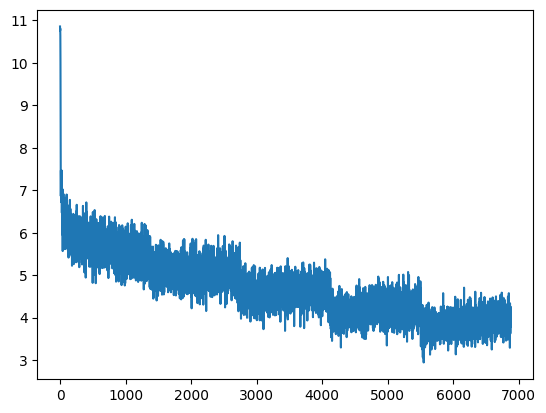

In [127]:
plt.plot(losses)

In [ ]:
val_ids = id_val_bengali

In [129]:
val_outs = []
for i in tqdm(range(len (test_ds))):
  encoder_hidden = torch.zeros(1, 1, hidden_size).to(device)
  input_tensor = test_ds[i][0].unsqueeze(dim=0).to(device)
  result = []
  with torch.set_grad_enabled(False):
    encoder_output, encoder_hidden = encoder(input_tensor, encoder_hidden)
    decoder_input = torch.tensor([SOS]).unsqueeze(dim=0).to(device)
    decoder_hidden = encoder_hidden
    for di in range(1, target_length):
        decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
        best = decoder_output.argmax(1)
        result.append(de_index2word[best.to('cpu').item()])
        if best.item() == EOS:
            break

        decoder_input = best.unsqueeze(dim=0)
  result = [i for i in result if not i in ['<EOS>', '<PAD>', '<SOS>']]
  val_outs.append(" ".join(result))

100%|██████████| 9836/9836 [02:51<00:00, 57.43it/s]


In [ ]:
df0 = pd.DataFrame()
df0["ID"] = val_ids
df0["Translation"] = val_outs

In [ ]:
df0.to_csv('answersBengaliLSTM10Epochs.csv', index = False)

In [201]:
import pandas as pd
# df1 = pd.read_csv("answersBengaliTransformer1_2-2.csv") # Bengali
# df2= pd.read_csv("answersHindiTransformer1-2.csv")  # Hindi

df1 = pd.read_csv("Bengali_Test2.csv") # Bengali
df2= pd.read_csv("Hindi_TestCNN3.csv")  # Hindi


In [202]:
df3 = pd.concat([df1, df2]) #Concat

In [203]:
df3

,ID,Translation
0,177039,বর্তমান ঘটনা
1,177040,ভগবান শিবকে উত্সর্গীকৃত হয়ে তার প্রতি স্বীকার ...
2,177041,ঘাড়ের যন্ত্রনায় পেয়ারা চূর্ণ করে ফুটিয়ে কুলকু...
3,177042,"এটা দেখে যে বাচ্চার জন্মের সময় মা , কোমর ব্যাথ..."
4,177043,অস্ট্রেলিয়ার উল্লেখযোগ্য পরিমাণ যা ডাল - এর চা...
...,...,...
23080,563219,उसे एक ईमेल भेजें और उसे पूछें कि वह कैसे है क...
23081,563220,"बोस की पहल पर , उड़ीसा के सरकार ने एक संस्थान ..."
23082,563221,पूर्व प्रवेश द्वार में फैले हुए कांच की थैली म...
23083,563222,सिर के साथ घुटने से नीचे की ओर झुकते बाद हाथों...


In [204]:
df3.to_csv('answersTest5.csv', index = False)

In [205]:
filtered_data = pd.read_csv("answersTest5.csv")

In [206]:
#answer = "/content/answer.csv"
answer = "answersTest5.csv"
with open(answer, "w") as f:
  f.writelines("ID\tTranslation\n")
  for i in range(filtered_data.shape[0]):
    f.writelines(f'{filtered_data["ID"][i]}\t"{filtered_data["Translation"][i]}"\n')

### Make a zip file of answer.csv and save it as submission.zip and submit it